# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [3]:
import pandas as pd

df = pd.read_csv('Employee_productivity.csv')

df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


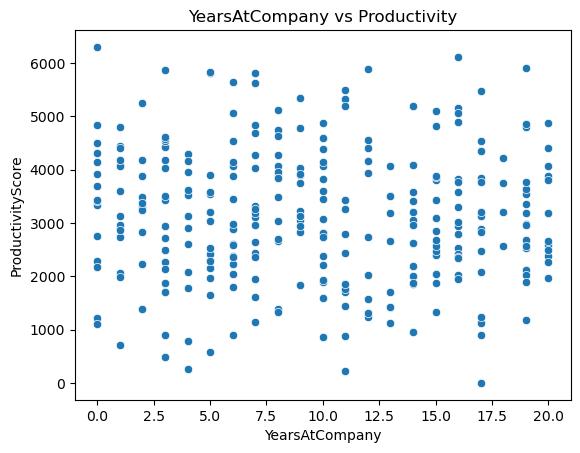

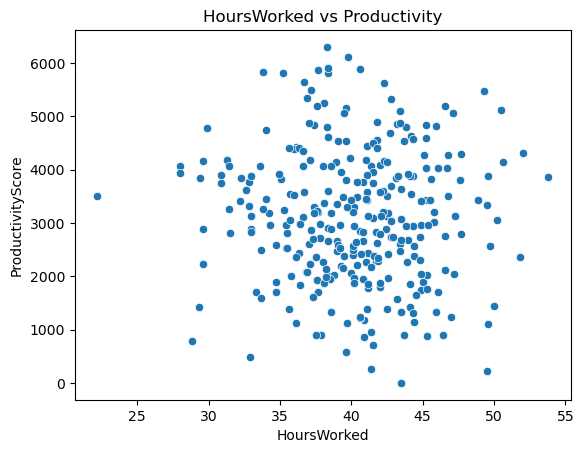

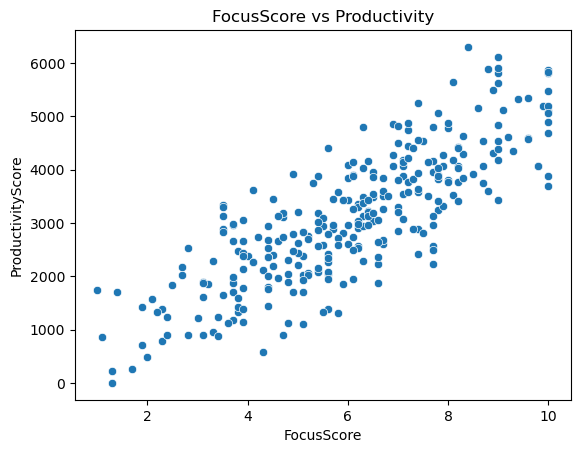

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ["YearsAtCompany", "HoursWorked", "FocusScore"]

for f in features:
    sns.scatterplot(x=f, y="ProductivityScore", data=df)
    plt.title(f"{f} vs Productivity")
    plt.show()

In [ ]:
# FocusScore had the strongest linear relationship with productivity based on the highest R² value.
# The scatterplot showed a clear upward trend, while HoursWorked and YearsAtCompany were weaker.

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

results = []

for f in features:
    X = df[[f]]
    y = df["ProductivityScore"]

    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)

    results.append((f, r2))

print(sorted(results, key=lambda x: x[1], reverse=True))

[('FocusScore', 0.6776960770307456), ('HoursWorked', 0.0025999350022654077), ('YearsAtCompany', 0.00041152919389664255)]


C:\Users\manny\AppData\Roaming\Python\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


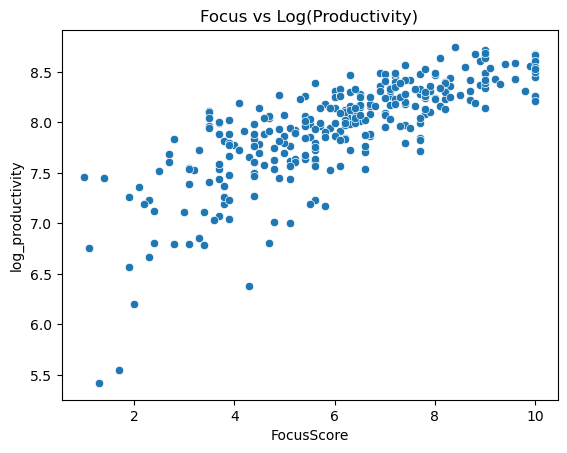

In [8]:
import numpy as np

df["log_productivity"] = np.log(df["ProductivityScore"])

# test with strongest feature (likely FocusScore)
sns.scatterplot(x="FocusScore", y="log_productivity", data=df)
plt.title("Focus vs Log(Productivity)")
plt.show()

In [10]:
X = df.drop(columns=["ProductivityScore", "log_productivity"], errors="ignore")
X = pd.get_dummies(X, drop_first=True)

# remove any inf values just in case
X = X.replace([float("inf"), float("-inf")], pd.NA)
X = X.dropna()

y = df.loc[X.index, "ProductivityScore"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("Full Model R²:", r2_score(y, y_pred))

Full Model R²: 0.6851104801306642


In [ ]:
# The full regression model (R² ≈ 0.685) shows productivity is influenced by multiple factors.
# FocusScore had the biggest positive impact, while some features like desk location and hours worked had weaker or negative effects.

In [11]:
coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print(coeffs)

                       Feature  Coefficient
1                   FocusScore   512.719278
3          TeamMeetingsPerWeek    27.170621
2               YearsAtCompany     3.400789
0                  HoursWorked    -4.664225
6             Department_Sales   -49.817366
4                Department_HR   -93.398401
7  DeskLocation_Private Office  -103.411959
5         Department_Marketing  -136.240520
8          DeskLocation_Remote  -229.752983


In [13]:
# Focus isthe biggest factor affecting productivity, so improving employee focus should be the main priority. Too many meetings and distractions likely reduce productivity, so cutting unnecessary meetings would help people stay on track. The data also shows that working more hours doesn’t really improve productivity, so the company should focus on making regular work time more efficient instead of relying on overtime. Overall, creating a better work environment with fewer distractions and more flexibility would help employees be more productive.